# H3: Animal Symbolism Clustering

**Purpose:** Construct the animal symbolic cluster variable needed to test H3 (animal symbolism moderates gender × religion effects on W−C asymmetry).

Three approaches, layered for convergent validity:

| Section | Approach | Level | Role |
|---------|----------|-------|------|
| 1 | Theory-driven clusters (Panofsky) | Artwork | **Primary** |
| 2 | Data-driven clustering (co-occurrence) | Artwork | Robustness |
| 3 | Caption keyword extraction | Figure | Validation |

**Outputs:**
- `animal_cluster` column added to analytical dataframe (purity / power / other / none)
- Convergence report between the three methods
- Figures for the paper: cluster distribution, religious × cluster crosstabs

## 0. Setup & Schema Introspection

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Style ──
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'figure.figsize': (10, 6),
    'font.size': 11
})

# ── Database connection ──
# UPDATE THIS PATH to match your machine
DB_PATH = '/home/agrupa-lab/agrupa/agrupa.sqlite'
conn = sqlite3.connect(DB_PATH)
print(f'Connected to {DB_PATH}')

Connected to /home/agrupa-lab/agrupa/agrupa.sqlite


In [2]:
# ── Introspect: what tables exist? ──
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
print('Tables in DB:')
for t in tables['name']:
    cols = pd.read_sql(f"PRAGMA table_info('{t}')", conn)
    print(f"  {t}: {', '.join(cols['name'].tolist())}")

Tables in DB:
  artwork: cat_no, titulo, autor, escuela_obra, ubicacion, medidas, tecnicas, soporte, materia, otros_no_inv, fecha_ingreso, forma_ingreso, procedencia, tipo_objeto, datacion, tema, pais_ubicacion, comunidad_ubicacion, provincia_ubicacion, localidad_ubicacion, area_departamento, marco_obra_actual, is_religious, is_fauna, century, image_path, descripcion, animal_cluster
  artwork_descriptor: cat_no, descriptor
  artwork_image: cat_no, file_name, file_path, extension, file_size_kb
  artwork_sadcat: cat_no, n_descriptores_fila, n_en_diccionario_fila, cov_pct_global, cov_Sociability_dict_pct, cov_Morality_dict_pct, cov_Ability_dict_pct, cov_Agency_dict_pct, cov_health_dict_pct, cov_Status_dict_pct, cov_work_dict_pct, cov_Politics_dict_pct, cov_Religion_dict_pct, cov_beliefsother_dict_pct, cov_inhabitant_dict_pct, cov_country_dict_pct, cov_feeling_dict_pct, cov_relative_dict_pct, cov_clothing_dict_pct, cov_ordinariness_dict_pct, cov_bodpart_dict_pct, cov_bodprop_dict_pct, cov_

In [3]:
# ── Introspect figures_m specifically ──
fig_cols = pd.read_sql("PRAGMA table_info('figures_m')", conn)
print('figures_m columns:')
display(fig_cols[['name', 'type']])

# Quick sample
display(pd.read_sql('SELECT * FROM figures_m LIMIT 3', conn))

figures_m columns:


,name,type
0,id,INTEGER
1,cat_no,TEXT
2,context,TEXT
3,figure_num,INTEGER
4,gender,TEXT
5,qualifier,TEXT
6,descriptor_text,TEXT
7,descriptor_length,INTEGER
8,word_count,INTEGER
9,n_descriptors,INTEGER


,id,cat_no,context,figure_num,gender,qualifier,descriptor_text,descriptor_length,word_count,n_descriptors,...,n_dirmean_Status,n_dirmean_Beliefs,n_dirmean_health,n_dirmean_deviance,n_dirmean_beauty,n_dirmean_Politics,n_dirmean_Religion,asymmetry,model_id,created_at
0,1,P000001,secular,1,Female,None,The central female figure is reclining on a re...,370,61,30,...,1,0,0,0,0,0,0,0.166667,Qwen/Qwen2.5-VL-7B-Instruct,2026-03-15 13:19:17
1,2,P000001,secular,2,Female,None,"To the left of the central figure, another wom...",307,55,24,...,4,0,0,0,0,0,0,-0.357143,Qwen/Qwen2.5-VL-7B-Instruct,2026-03-15 13:19:17
2,3,P000001,secular,3,Female,None,"A third woman, positioned behind the central f...",327,53,24,...,1,0,1,1,0,0,0,-0.100000,Qwen/Qwen2.5-VL-7B-Instruct,2026-03-15 13:19:17


In [4]:
# ── Introspect fauna tag taxonomy ──
# Find the root 'fauna' tag
fauna_root = pd.read_sql("""
    SELECT tag_id, name, slug, depth 
    FROM icon_tag 
    WHERE slug = 'fauna' OR name LIKE '%Fauna%'
    ORDER BY depth
""", conn)
print('Fauna root tag(s):')
display(fauna_root)

# All fauna descendants via closure
fauna_tags = pd.read_sql("""
    SELECT t.tag_id, t.name, t.slug, t.depth, tc.depth AS closure_depth
    FROM icon_tag t
    JOIN tag_closure tc ON tc.descendant_id = t.tag_id
    JOIN icon_tag root ON tc.ancestor_id = root.tag_id
    WHERE root.slug = 'fauna'
    ORDER BY t.slug
""", conn)
print(f'\nTotal fauna tags in taxonomy: {len(fauna_tags)}')
display(fauna_tags)

Fauna root tag(s):


,tag_id,name,slug,depth
0,1,Fauna,fauna,0



Total fauna tags in taxonomy: 236


,tag_id,name,slug,depth,closure_depth
0,1,Fauna,fauna,0,0
1,2,Anfibios,fauna/anfibios,1,1
2,3,Rana,fauna/anfibios/rana,2,2
3,4,Salamandra,fauna/anfibios/salamandra,2,2
4,5,Sapo,fauna/anfibios/sapo,2,2
...,...,...,...,...,...
231,232,Cocodrilo,fauna/reptiles/cocodrilo,2,2
232,233,Lagartija,fauna/reptiles/lagartija,2,2
233,234,Sapo,fauna/reptiles/sapo,2,2
234,235,Serpiente,fauna/reptiles/serpiente,2,2


In [5]:
# ── Artwork counts per fauna leaf tag ──
# Using artwork_tag (minimized) for cleaner counts
fauna_counts = pd.read_sql("""
    SELECT t.tag_id, t.name, t.slug, t.depth, COUNT(DISTINCT at2.cat_no) AS n_artworks
    FROM icon_tag t
    JOIN tag_closure tc ON tc.descendant_id = t.tag_id
    JOIN icon_tag root ON tc.ancestor_id = root.tag_id
    JOIN artwork_tag at2 ON at2.tag_id = t.tag_id
    WHERE root.slug = 'fauna'
    GROUP BY t.tag_id
    ORDER BY n_artworks DESC
""", conn)

print(f'Fauna tags with artworks: {len(fauna_counts)}')
display(fauna_counts.head(25))

Fauna tags with artworks: 213


,tag_id,name,slug,depth,n_artworks
0,217,Perro (Canis lupus familiaris),fauna/mamiferos/perro-canis-lupus-familiaris,2,856
1,178,Caballo,fauna/mamiferos/caballo,2,763
2,215,Oveja (Ovis aries),fauna/mamiferos/oveja-ovis-aries,2,323
3,24,Aves,fauna/aves,1,195
4,172,Bovido,fauna/mamiferos/bovido,2,173
5,127,simbólica,fauna/aves/paloma/blanca/simbolica,4,163
6,169,Asno,fauna/mamiferos/asno,2,161
7,85,Gallo,fauna/aves/gallo,2,124
8,206,León (Panthera leo),fauna/mamiferos/leon-panthera-leo,2,119
9,23,Artropodos,fauna/artropodos,1,118


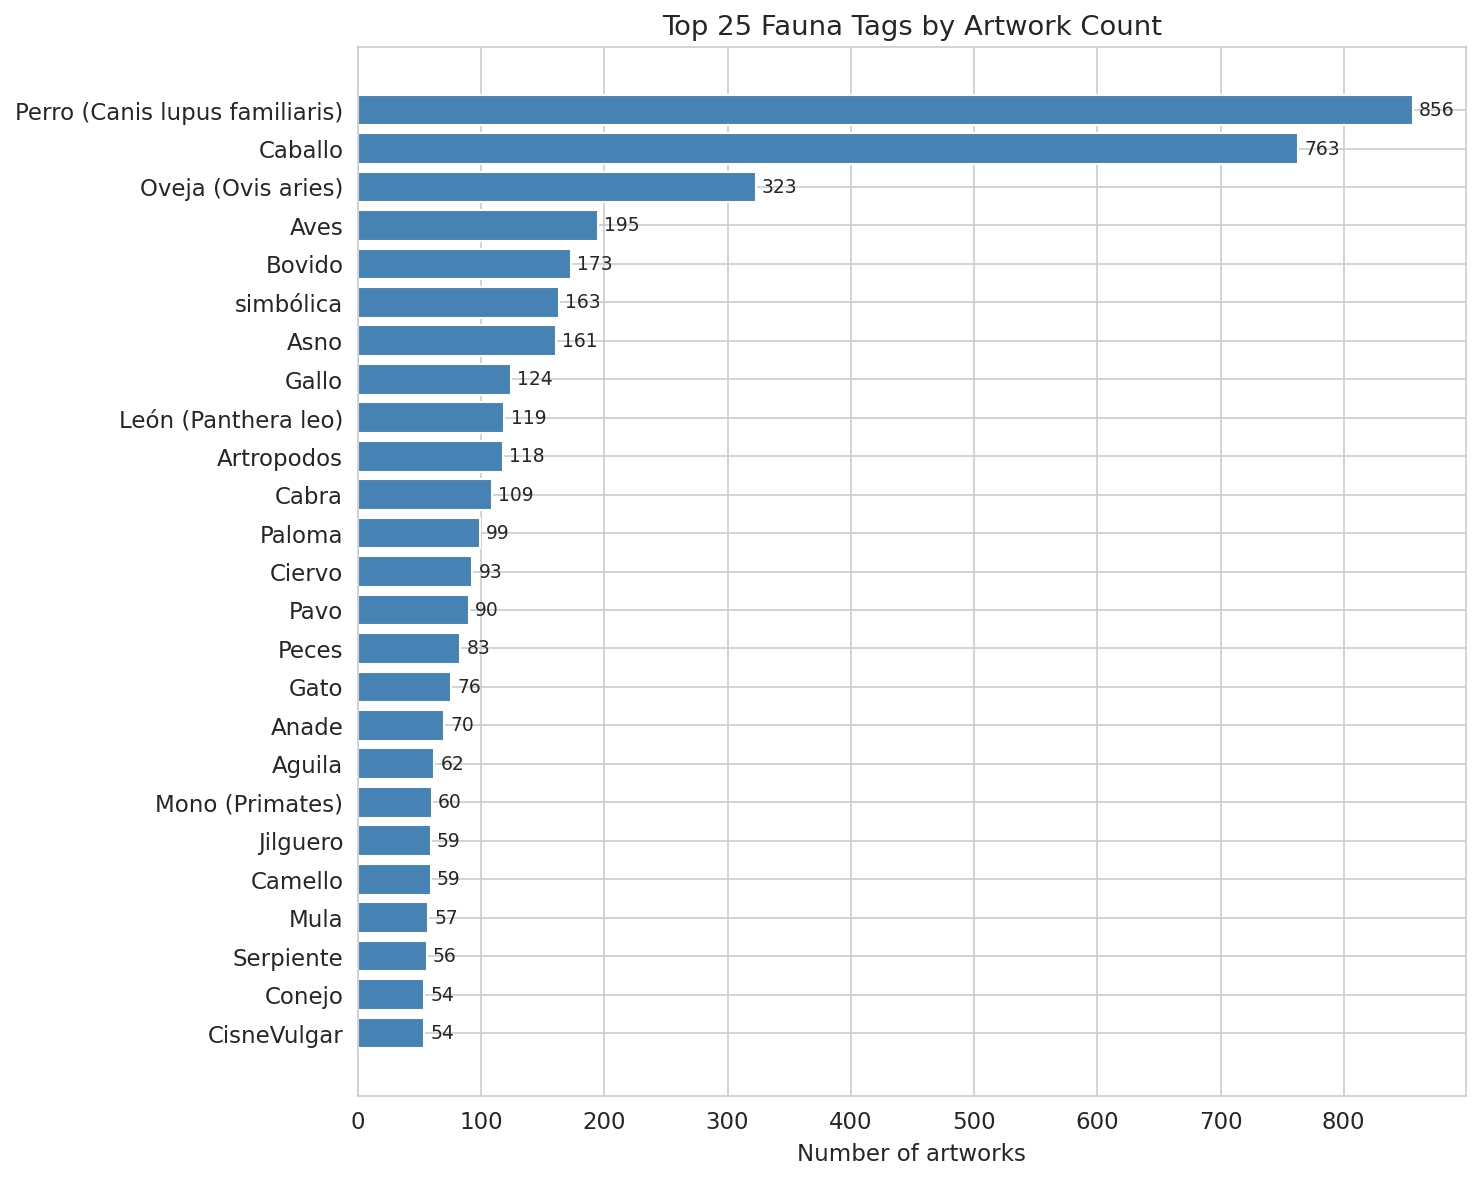

In [6]:
# ── Visualize: top fauna tags by artwork count ──
top_n = min(25, len(fauna_counts))
fig, ax = plt.subplots(figsize=(10, 8))
plot_data = fauna_counts.head(top_n).sort_values('n_artworks')
ax.barh(plot_data['name'], plot_data['n_artworks'], color='steelblue')
ax.set_xlabel('Number of artworks')
ax.set_title(f'Top {top_n} Fauna Tags by Artwork Count')
for i, (_, row) in enumerate(plot_data.iterrows()):
    ax.text(row['n_artworks'] + 5, i, str(row['n_artworks']), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/fauna_tag_distribution.png', bbox_inches='tight')
plt.show()

---
## 1. Theory-Driven Clusters (Primary)

Based on established Christian iconographic tradition (Panofsky, 1939; Hall, 1974; Ferguson, 1961), animals in Western religious art carry conventionalized symbolic meanings. We group them into two clusters:

| Cluster | Animals | Symbolic meaning | Iconographic basis |
|---------|---------|-----------------|--------------------|
| **Purity** | Lamb/sheep, dove, fish | Innocence, Holy Spirit, sacrifice, spiritual purity | Agnus Dei, Annunciation dove, ichthys |
| **Power** | Horse, eagle, lion, dragon/serpent | Authority, sovereignty, strength, spiritual combat | Royal/military mounts, evangelist symbols, St. George |

Animals not fitting either cluster (e.g., dog, cat, deer) are assigned to **"other"**. Artworks without fauna tags are **"none"**.

### Rationale
This is not an arbitrary grouping — it operationalizes the core argument of H3: that purity-coded animals co-occur with Marian/saintly feminine imagery (where female figures gain competence through sacred association), while power-coded animals co-occur with martial/sovereign imagery (where male-coded authority persists).

In [7]:
# ══════════════════════════════════════════════════════════════════
# 1.1  Define theory-driven cluster mappings
# ══════════════════════════════════════════════════════════════════
#
# These slug patterns will be matched against the icon_tag.slug column.
# Use partial matches (LIKE) because the taxonomy is hierarchical:
#   e.g. 'fauna/mamiferos/oveja' should match 'oveja'
#
# ── IMPORTANT: Inspect the fauna_counts output above and adjust
#    these keyword lists to match the actual slug/name values in YOUR DB.
#    The patterns below are best guesses based on the Prado taxonomy.

# Keywords to match in tag slug OR name (case-insensitive)
PURITY_KEYWORDS = [
    'cordero', 'oveja', 'lamb', 'sheep',    # Lamb / sheep
    'paloma', 'dove',                         # Dove
    'pez', 'peces', 'fish',                   # Fish (ichthys)
]

POWER_KEYWORDS = [
    'caballo', 'horse',                       # Horse
    'aguila', 'eagle',                         # Eagle
    'leon', 'lion',                            # Lion
    'dragon', 'serpiente', 'snake', 'serpent', # Dragon / serpent
]

def classify_tag(slug, name):
    """Classify a single fauna tag into purity/power/other."""
    slug_lower = slug.lower() if slug else ''
    name_lower = name.lower() if name else ''
    combined = slug_lower + ' ' + name_lower
    
    for kw in PURITY_KEYWORDS:
        if kw in combined:
            return 'purity'
    for kw in POWER_KEYWORDS:
        if kw in combined:
            return 'power'
    return 'other'

# Apply classification to all fauna tags
fauna_counts['theory_cluster'] = fauna_counts.apply(
    lambda r: classify_tag(r['slug'], r['name']), axis=1
)

print('Tag classification results:')
print(fauna_counts.groupby('theory_cluster')['n_artworks'].agg(['count', 'sum']))
print()

# Show full mapping for verification
for cluster in ['purity', 'power', 'other']:
    subset = fauna_counts[fauna_counts['theory_cluster'] == cluster]
    print(f"\n── {cluster.upper()} ({len(subset)} tags, {subset['n_artworks'].sum()} artwork-tag links) ──")
    for _, row in subset.iterrows():
        print(f"  {row['slug']:40s} n={row['n_artworks']:>5d}")

Tag classification results:
                count   sum
theory_cluster             
other             186  3923
power               9  1061
purity             18   686


── PURITY (18 tags, 686 artwork-tag links) ──
  fauna/mamiferos/oveja-ovis-aries         n=  323
  fauna/aves/paloma/blanca/simbolica       n=  163
  fauna/aves/paloma                        n=   99
  fauna/peces                              n=   83
  fauna/peces/besugo                       n=    3
  fauna/peces/anguila                      n=    2
  fauna/aves/paloma/torcaz                 n=    2
  fauna/peces/salmon                       n=    1
  fauna/peces/rodaballo                    n=    1
  fauna/peces/raya                         n=    1
  fauna/peces/pez-volador                  n=    1
  fauna/peces/pez-inventado                n=    1
  fauna/peces/merluza                      n=    1
  fauna/peces/congrio                      n=    1
  fauna/peces/arenques                     n=    1
  fauna/aves/paloma

In [8]:
# ══════════════════════════════════════════════════════════════════
# 1.2  Assign artwork-level cluster
# ══════════════════════════════════════════════════════════════════
#
# Logic: for each artwork, collect all its fauna tags.
# If ANY tag is purity -> purity (dominant signal for H3).
# If ANY tag is power (and none purity) -> power.
# If fauna tags exist but all are 'other' -> other.
# If no fauna tags -> none.
#
# NOTE: artworks with BOTH purity and power tags are assigned 'purity'
# by default. We'll check how many of these exist and can create a
# 'mixed' category if needed.

# Get all artwork-fauna tag assignments
artwork_fauna = pd.read_sql("""
    SELECT DISTINCT at2.cat_no, t.tag_id, t.name, t.slug
    FROM artwork_tag at2
    JOIN icon_tag t ON at2.tag_id = t.tag_id
    JOIN tag_closure tc ON tc.descendant_id = t.tag_id
    JOIN icon_tag root ON tc.ancestor_id = root.tag_id
    WHERE root.slug = 'fauna'
""", conn)

print(f'Total artwork-fauna links: {len(artwork_fauna)}')
print(f'Unique artworks with fauna: {artwork_fauna["cat_no"].nunique()}')

# Classify each link
artwork_fauna['theory_cluster'] = artwork_fauna.apply(
    lambda r: classify_tag(r['slug'], r['name']), axis=1
)

Total artwork-fauna links: 5670
Unique artworks with fauna: 2813


In [9]:
# ── Resolve artwork-level cluster (priority: purity > power > other) ──
def resolve_artwork_cluster(group):
    clusters = set(group['theory_cluster'])
    has_purity = 'purity' in clusters
    has_power = 'power' in clusters
    
    if has_purity and has_power:
        return 'mixed'  # We'll inspect these
    elif has_purity:
        return 'purity'
    elif has_power:
        return 'power'
    else:
        return 'other'

artwork_cluster = (
    artwork_fauna
    .groupby('cat_no')
    .apply(resolve_artwork_cluster)
    .reset_index()
    .rename(columns={0: 'animal_cluster'})
)

print('Artwork-level cluster distribution:')
print(artwork_cluster['animal_cluster'].value_counts())
print(f"\nMixed (both purity + power): {(artwork_cluster['animal_cluster'] == 'mixed').sum()}")

Artwork-level cluster distribution:
animal_cluster
other     1285
power      873
purity     539
mixed      116
Name: count, dtype: int64

Mixed (both purity + power): 116


In [10]:
# ── Decision: how to handle 'mixed' ──
# If mixed count is small, fold into 'purity' (dominant signal).
# If large, keep as separate category.
mixed_n = (artwork_cluster['animal_cluster'] == 'mixed').sum()
print(f'Mixed artworks: {mixed_n}')

if mixed_n < 50:
    print('→ Folding mixed into purity (small n, purity takes priority)')
    artwork_cluster.loc[
        artwork_cluster['animal_cluster'] == 'mixed', 'animal_cluster'
    ] = 'purity'
else:
    print('→ Keeping mixed as separate category (substantial n)')

print('\nFinal artwork-level cluster distribution:')
print(artwork_cluster['animal_cluster'].value_counts())

Mixed artworks: 116
→ Keeping mixed as separate category (substantial n)

Final artwork-level cluster distribution:
animal_cluster
other     1285
power      873
purity     539
mixed      116
Name: count, dtype: int64


In [11]:
# ══════════════════════════════════════════════════════════════════
# 1.3  Merge with full analytical corpus
# ══════════════════════════════════════════════════════════════════

# Get all artworks in the analytical corpus (those with images)
all_artworks = pd.read_sql("""
    SELECT DISTINCT cat_no FROM artwork_image
""", conn)

# Merge — artworks without fauna get 'none'
all_artworks = all_artworks.merge(artwork_cluster, on='cat_no', how='left')
all_artworks['animal_cluster'] = all_artworks['animal_cluster'].fillna('none')

print('Full corpus cluster distribution:')
print(all_artworks['animal_cluster'].value_counts())
print(f'\nTotal: {len(all_artworks)}')

Full corpus cluster distribution:
animal_cluster
none      5042
other     1085
power      727
purity     466
mixed      109
Name: count, dtype: int64

Total: 7429


In [12]:
# ══════════════════════════════════════════════════════════════════
# 1.4  Cross-tabulate: cluster × religious context
# ══════════════════════════════════════════════════════════════════

# Get is_religious flag (assuming it's stored in artwork table or as a view)
# Try to find it — it might be a column in artwork or a separate flag
try:
    religious_flags = pd.read_sql("""
        SELECT cat_no, is_religious FROM artwork
    """, conn)
except:
    # If not a column, reconstruct from tags
    print('is_religious not in artwork table — reconstructing from tags...')
    religious_flags = pd.read_sql("""
        SELECT DISTINCT at2.cat_no, 1 AS is_religious
        FROM artwork_tag at2
        JOIN tag_closure tc ON tc.descendant_id = at2.tag_id
        JOIN icon_tag root ON tc.ancestor_id = root.tag_id
        WHERE root.slug LIKE '%religion%'
           OR root.slug LIKE '%temas/religion%'
    """, conn)

corpus = all_artworks.merge(religious_flags, on='cat_no', how='left')
corpus['is_religious'] = corpus['is_religious'].fillna(0).astype(int)

# Cross-tab
ct = pd.crosstab(
    corpus['animal_cluster'], 
    corpus['is_religious'].map({0: 'Secular', 1: 'Religious'}),
    margins=True
)
print('Animal Cluster × Religious Context:')
display(ct)

Animal Cluster × Religious Context:


is_religious,Religious,Secular,All
animal_cluster,,,
mixed,42,67,109
none,1780,3262,5042
other,254,831,1085
power,217,510,727
purity,288,178,466
All,2581,4848,7429


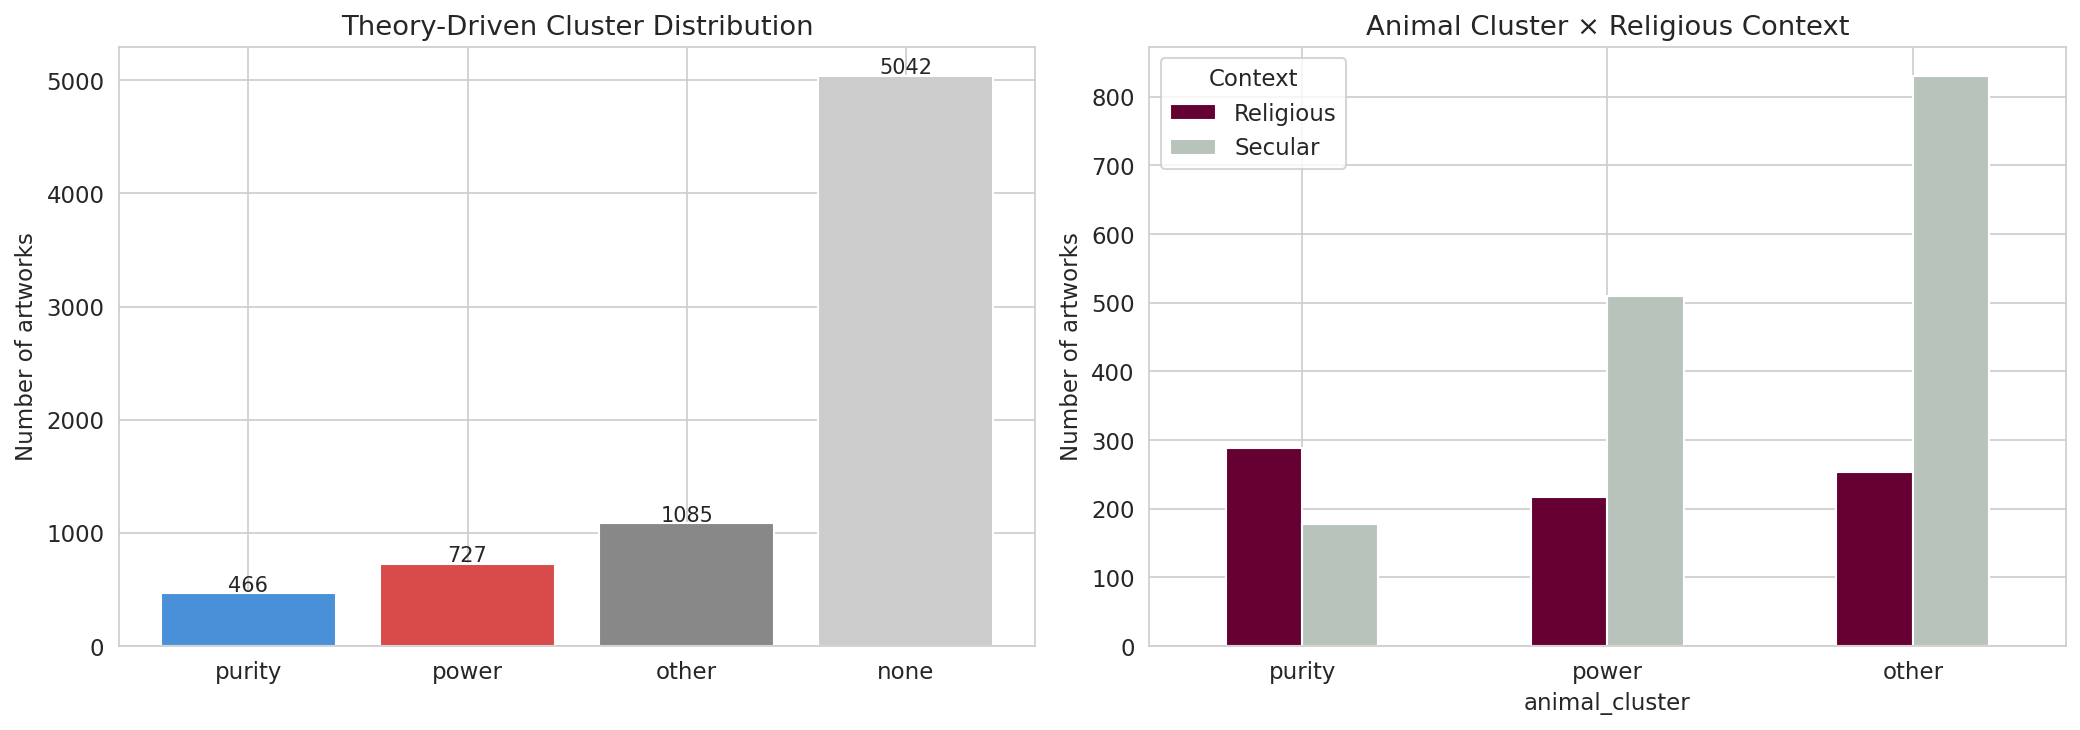

In [13]:
# ── Visualization: cluster × religious mosaic ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: cluster distribution
order = ['purity', 'power', 'other', 'none']
colors = {'purity': '#4A90D9', 'power': '#D94A4A', 'other': '#888888', 'none': '#CCCCCC'}
cluster_counts = corpus['animal_cluster'].value_counts().reindex(order)
axes[0].bar(order, cluster_counts.values, color=[colors[c] for c in order])
axes[0].set_ylabel('Number of artworks')
axes[0].set_title('Theory-Driven Cluster Distribution')
for i, v in enumerate(cluster_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Grouped bar: cluster × religious
ct_plot = ct.drop('All', axis=0).drop('All', axis=1)
ct_plot = ct_plot.reindex(order[:3])  # exclude 'none' for this plot
ct_plot.plot(kind='bar', ax=axes[1], color=['#660033', '#B8C4BB'])
axes[1].set_ylabel('Number of artworks')
axes[1].set_title('Animal Cluster × Religious Context')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Context')

plt.tight_layout()
plt.savefig('../figures/theory_cluster_distribution.png', bbox_inches='tight')
plt.show()

In [14]:
# ══════════════════════════════════════════════════════════════════
# 1.5  Feasibility check: do we have enough n per cell?
# ══════════════════════════════════════════════════════════════════
#
# For H3 testing we need: figures in religious artworks with purity/power
# animals, split by gender. Let's check the cell sizes.

# Merge cluster into figures_m
figures = pd.read_sql('SELECT * FROM figures_m', conn)
figures = figures.merge(corpus[['cat_no', 'animal_cluster', 'is_religious']], on='cat_no', how='left')

# Filter to Male/Female only (exclude Unknown)
# Adjust column name if needed based on introspection above
gender_col = [c for c in figures.columns if 'gender' in c.lower()][0]
print(f'Using gender column: {gender_col}')

fig_mf = figures[figures[gender_col].isin(['MALE', 'FEMALE', 'Male', 'Female'])].copy()
fig_mf[gender_col] = fig_mf[gender_col].str.upper()

# Cell counts: gender × religious × animal_cluster
cell_counts = (
    fig_mf
    .groupby([gender_col, 'is_religious', 'animal_cluster'])
    .size()
    .reset_index(name='n_figures')
)

print('\nCell sizes for H3 modeling:')
display(
    cell_counts.pivot_table(
        index='animal_cluster', 
        columns=[gender_col, 'is_religious'], 
        values='n_figures',
        fill_value=0
    )
)

# Flag cells below threshold
MIN_CELL = 30
small_cells = cell_counts[cell_counts['n_figures'] < MIN_CELL]
if len(small_cells) > 0:
    print(f'\n⚠️  Cells below n={MIN_CELL}:')
    display(small_cells)
else:
    print(f'\n✅ All cells have n ≥ {MIN_CELL}')

Using gender column: gender

Cell sizes for H3 modeling:


gender          FEMALE            MALE        
is_religious         0       1       0       1
animal_cluster                                
mixed            105.0    61.0   208.0   111.0
none            2230.0  1683.0  3234.0  3160.0
other            985.0   316.0  1662.0   583.0
power            532.0   230.0  1507.0   576.0
purity           221.0   393.0   327.0   637.0


✅ All cells have n ≥ 30


---
## 2. Data-Driven Clustering (Robustness)

Here we let the data speak: build a co-occurrence matrix of fauna tags across artworks, then cluster hierarchically. The goal is to check whether the clusters that emerge empirically resemble the theory-driven groupings.

We run this twice:
- **2A: All fauna tags** (including broad categories like 'mamiferos', 'aves')
- **2B: Species-level only** (depth ≥ 2, the actual animals)

In [15]:
# ══════════════════════════════════════════════════════════════════
# 2.0  Build artwork × fauna tag binary matrix
# ══════════════════════════════════════════════════════════════════

# All fauna tags (from artwork_tag minimized)
af_all = pd.read_sql("""
    SELECT at2.cat_no, t.tag_id, t.name, t.slug, t.depth
    FROM artwork_tag at2
    JOIN icon_tag t ON at2.tag_id = t.tag_id
    JOIN tag_closure tc ON tc.descendant_id = t.tag_id
    JOIN icon_tag root ON tc.ancestor_id = root.tag_id
    WHERE root.slug = 'fauna'
""", conn)

print(f'All fauna links: {len(af_all)}')
print(f'Unique tags: {af_all["tag_id"].nunique()}, Unique artworks: {af_all["cat_no"].nunique()}')
print(f'\nDepth distribution:')
print(af_all.groupby('depth')['tag_id'].nunique())

All fauna links: 5670
Unique tags: 213, Unique artworks: 2813

Depth distribution:
depth
0      1
1      6
2    162
3     40
4      4
Name: tag_id, dtype: int64


In [16]:
def build_cooccurrence_and_cluster(af_df, label, min_artworks=20):
    """
    Build co-occurrence matrix, compute Jaccard distance, run 
    hierarchical clustering, and visualize.
    
    Parameters
    ----------
    af_df : DataFrame with columns [cat_no, tag_id, name, slug]
    label : str, used in plot titles
    min_artworks : int, minimum artworks for a tag to be included
    
    Returns
    -------
    linkage_matrix, tag_labels, binary_matrix
    """
    # Filter to tags with enough artworks
    tag_counts = af_df.groupby(['tag_id', 'name'])['cat_no'].nunique().reset_index()
    tag_counts.columns = ['tag_id', 'name', 'n']
    keep_tags = tag_counts[tag_counts['n'] >= min_artworks]['tag_id'].tolist()
    
    af_filt = af_df[af_df['tag_id'].isin(keep_tags)].copy()
    print(f'[{label}] Tags with ≥{min_artworks} artworks: {len(keep_tags)}')
    
    if len(keep_tags) < 3:
        print(f'  ⚠️  Too few tags for clustering. Try lowering min_artworks.')
        return None, None, None
    
    # Pivot to binary matrix: artworks × tags
    binary = af_filt.assign(val=1).pivot_table(
        index='cat_no', columns='tag_id', values='val', fill_value=0
    )
    
    # Co-occurrence: tag × tag (how many artworks share both tags)
    cooc = binary.T.dot(binary)
    
    # Jaccard distance: 1 - |A∩B| / |A∪B|
    n_artworks_per_tag = binary.sum(axis=0)
    n_tags = len(cooc)
    jaccard_dist = np.zeros((n_tags, n_tags))
    
    for i in range(n_tags):
        for j in range(i+1, n_tags):
            intersection = cooc.iloc[i, j]
            union = n_artworks_per_tag.iloc[i] + n_artworks_per_tag.iloc[j] - intersection
            jaccard_dist[i, j] = 1 - (intersection / union) if union > 0 else 1
            jaccard_dist[j, i] = jaccard_dist[i, j]
    
    # Tag labels
    tag_id_to_name = dict(zip(tag_counts['tag_id'], tag_counts['name']))
    tag_labels = [tag_id_to_name.get(tid, str(tid)) for tid in binary.columns]
    
    # Hierarchical clustering (Ward's method on Jaccard distance)
    condensed = squareform(jaccard_dist)
    Z = linkage(condensed, method='average')  # average linkage for Jaccard
    
    return Z, tag_labels, jaccard_dist, binary

[All fauna tags] Tags with ≥20 artworks: 50


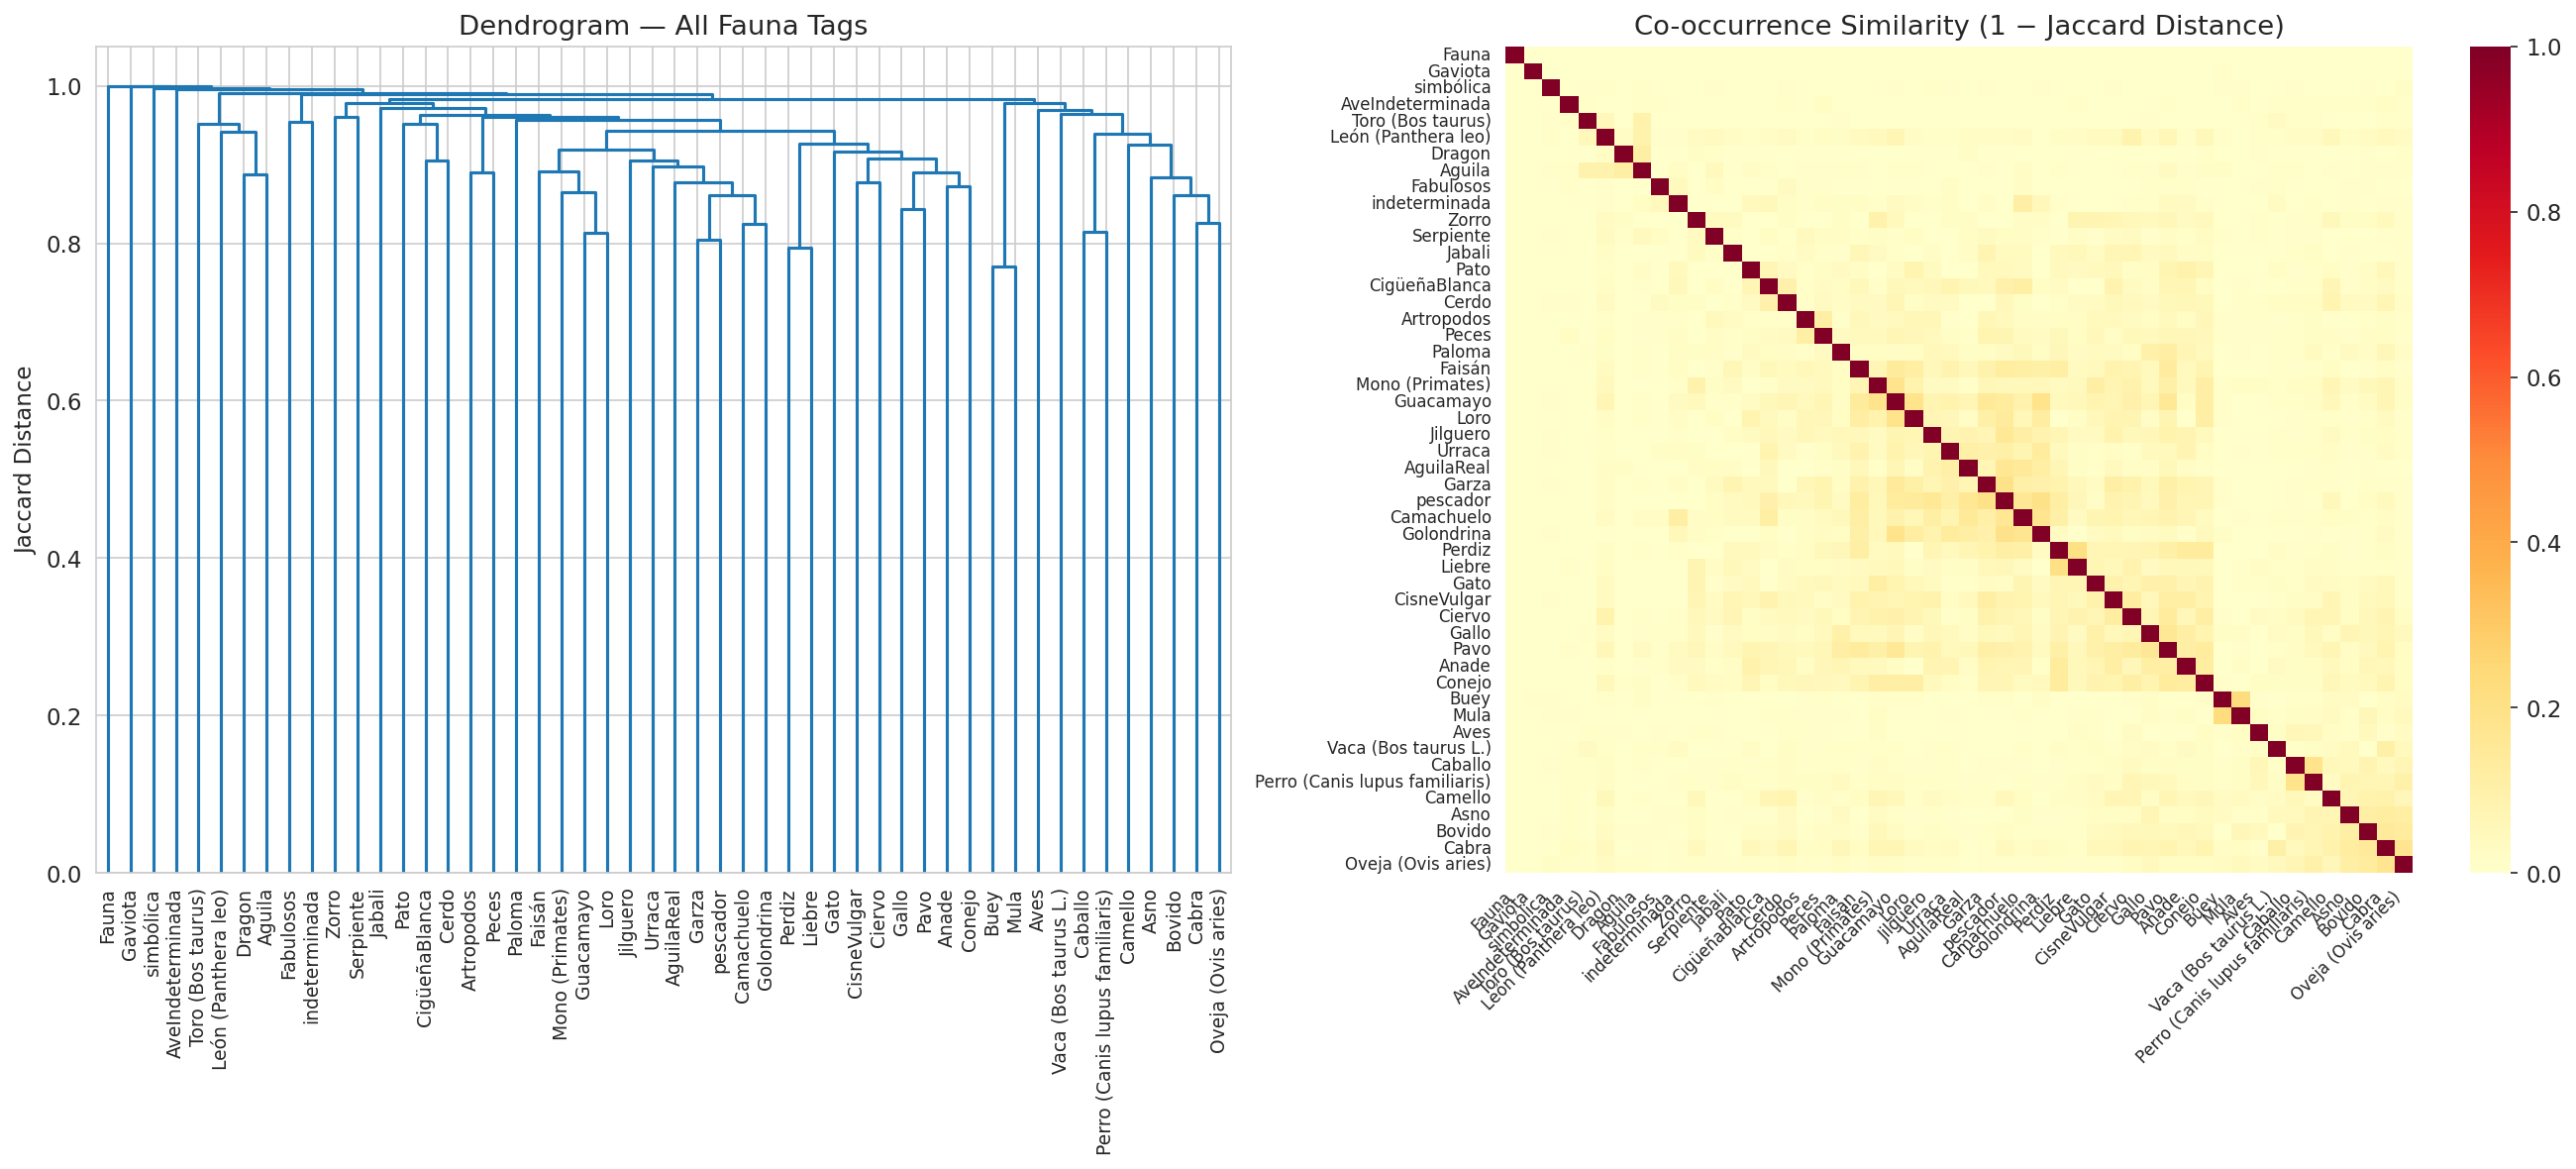

In [17]:
# ══════════════════════════════════════════════════════════════════
# 2A: All fauna tags
# ══════════════════════════════════════════════════════════════════
Z_all, labels_all, dist_all, binary_all = build_cooccurrence_and_cluster(
    af_all, 'All fauna tags', min_artworks=20
)

if Z_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Dendrogram
    dendrogram(Z_all, labels=labels_all, ax=axes[0], leaf_rotation=90, leaf_font_size=9)
    axes[0].set_title('Dendrogram — All Fauna Tags')
    axes[0].set_ylabel('Jaccard Distance')
    
    # Heatmap
    from scipy.cluster.hierarchy import leaves_list
    order = leaves_list(Z_all)
    ordered_labels = [labels_all[i] for i in order]
    ordered_dist = dist_all[np.ix_(order, order)]
    
    sns.heatmap(
        1 - ordered_dist,  # similarity
        xticklabels=ordered_labels, yticklabels=ordered_labels,
        cmap='YlOrRd', ax=axes[1], vmin=0, vmax=1
    )
    axes[1].set_title('Co-occurrence Similarity (1 − Jaccard Distance)')
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(axes[1].get_yticklabels(), fontsize=8)
    
    plt.tight_layout()
    plt.savefig('../figures/clustering_all_fauna.png', bbox_inches='tight')
    plt.show()

Species-level tags: 206
[Species-level fauna] Tags with ≥15 artworks: 56


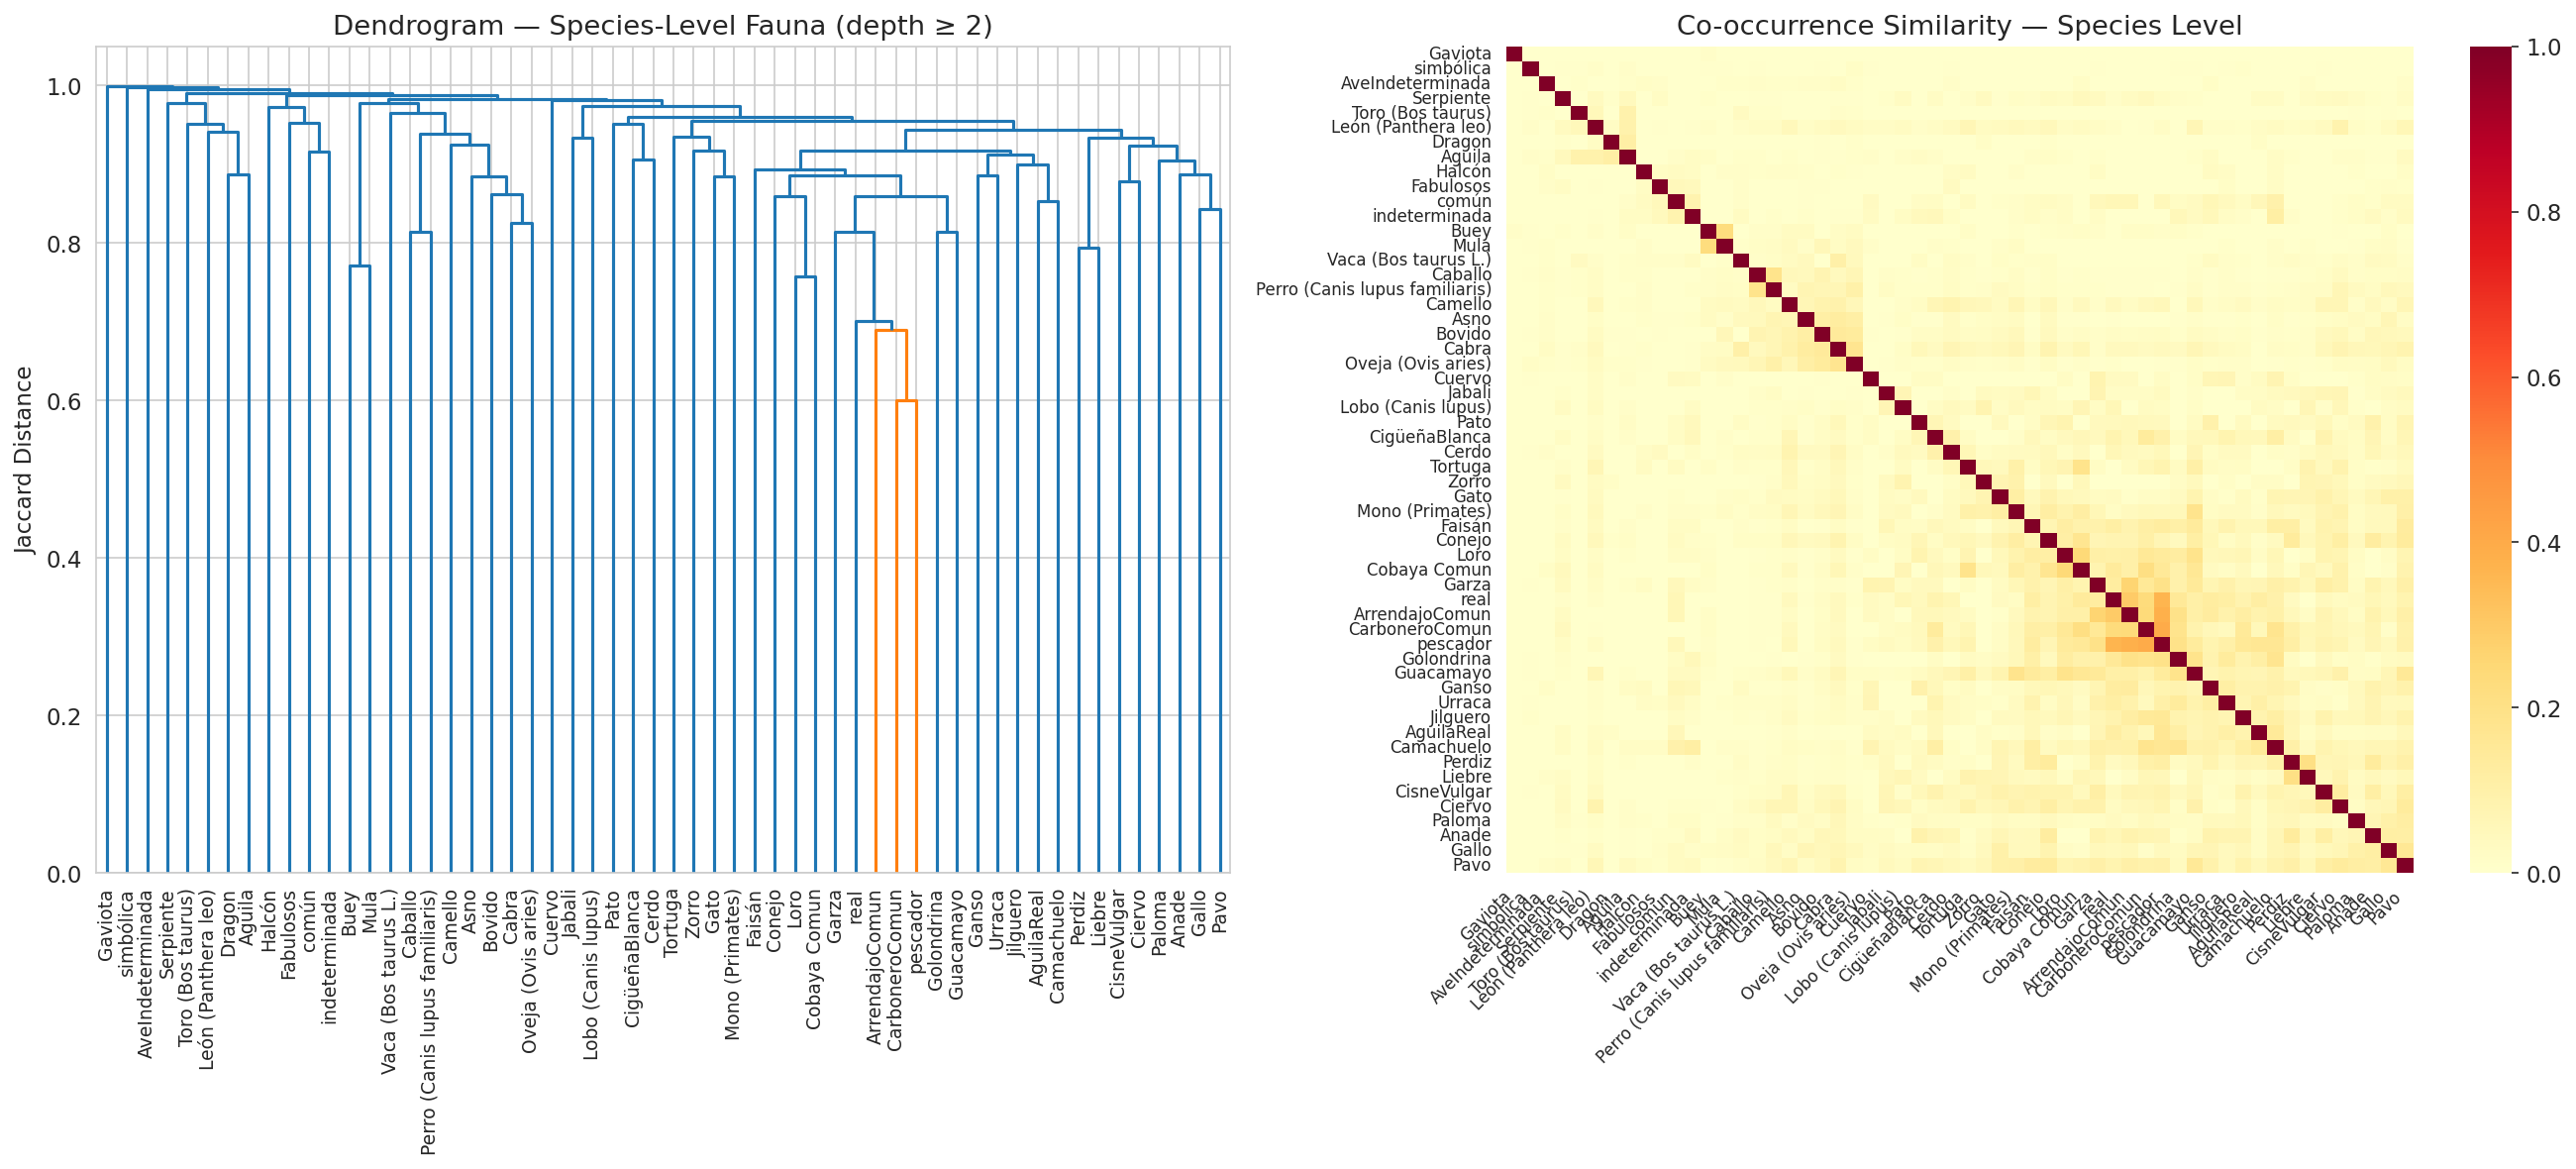

In [18]:
# ══════════════════════════════════════════════════════════════════
# 2B: Species-level only (depth ≥ 2)
# ══════════════════════════════════════════════════════════════════
af_species = af_all[af_all['depth'] >= 2].copy()
print(f'Species-level tags: {af_species["tag_id"].nunique()}')

Z_sp, labels_sp, dist_sp, binary_sp = build_cooccurrence_and_cluster(
    af_species, 'Species-level fauna', min_artworks=15
)

if Z_sp is not None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    dendrogram(Z_sp, labels=labels_sp, ax=axes[0], leaf_rotation=90, leaf_font_size=9)
    axes[0].set_title('Dendrogram — Species-Level Fauna (depth ≥ 2)')
    axes[0].set_ylabel('Jaccard Distance')
    
    from scipy.cluster.hierarchy import leaves_list
    order_sp = leaves_list(Z_sp)
    ordered_labels_sp = [labels_sp[i] for i in order_sp]
    ordered_dist_sp = dist_sp[np.ix_(order_sp, order_sp)]
    
    sns.heatmap(
        1 - ordered_dist_sp,
        xticklabels=ordered_labels_sp, yticklabels=ordered_labels_sp,
        cmap='YlOrRd', ax=axes[1], vmin=0, vmax=1
    )
    axes[1].set_title('Co-occurrence Similarity — Species Level')
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(axes[1].get_yticklabels(), fontsize=8)
    
    plt.tight_layout()
    plt.savefig('../figures/clustering_species_fauna.png', bbox_inches='tight')
    plt.show()

In [19]:
# ══════════════════════════════════════════════════════════════════
# 2C: Cut dendrogram and compare to theory clusters
# ══════════════════════════════════════════════════════════════════

def compare_to_theory(Z, labels, binary_df, af_df, k_range=[2, 3, 4, 5]):
    """
    Cut the dendrogram at different k values and compare
    the resulting clusters to the theory-driven classification.
    """
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    
    # Get theory labels for each tag in the clustering
    tag_ids = binary_df.columns.tolist()
    tag_info = af_df[['tag_id', 'slug', 'name']].drop_duplicates()
    tag_info = tag_info.set_index('tag_id')
    
    theory_labels = []
    for tid in tag_ids:
        if tid in tag_info.index:
            row = tag_info.loc[tid]
            slug = row['slug'] if isinstance(row, pd.Series) else row['slug'].iloc[0]
            name = row['name'] if isinstance(row, pd.Series) else row['name'].iloc[0]
            theory_labels.append(classify_tag(slug, name))
        else:
            theory_labels.append('other')
    
    results = []
    for k in k_range:
        data_labels = fcluster(Z, k, criterion='maxclust')
        ari = adjusted_rand_score(theory_labels, data_labels)
        nmi = normalized_mutual_info_score(theory_labels, data_labels)
        results.append({'k': k, 'ARI': round(ari, 3), 'NMI': round(nmi, 3)})
        
        # Print cluster composition
        print(f'\n── k={k} (ARI={ari:.3f}, NMI={nmi:.3f}) ──')
        for c in sorted(set(data_labels)):
            members = [labels[i] for i in range(len(labels)) if data_labels[i] == c]
            theories = [theory_labels[i] for i in range(len(labels)) if data_labels[i] == c]
            theory_dist = Counter(theories)
            print(f'  Cluster {c}: {members}')
            print(f'    Theory composition: {dict(theory_dist)}')
    
    return pd.DataFrame(results)

# Run comparison on species-level (more interpretable)
if Z_sp is not None:
    print('═══ Comparing data-driven clusters to theory (species level) ═══')
    convergence_sp = compare_to_theory(Z_sp, labels_sp, binary_sp, af_species)
    print('\nConvergence metrics:')
    display(convergence_sp)

═══ Comparing data-driven clusters to theory (species level) ═══

── k=2 (ARI=-0.029, NMI=0.010) ──
  Cluster 1: ['Fabulosos', 'Dragon', 'Aguila', 'AguilaReal', 'Anade', 'ArrendajoComun', 'AveIndeterminada', 'Camachuelo', 'CarboneroComun', 'CigüeñaBlanca', 'CisneVulgar', 'Cuervo', 'Faisán', 'Gallo', 'Ganso', 'Garza', 'Golondrina', 'Guacamayo', 'Halcón', 'Jilguero', 'común', 'Loro', 'pescador', 'Paloma', 'simbólica', 'Pato', 'Pavo', 'Perdiz', 'real', 'indeterminada', 'Urraca', 'Asno', 'Bovido', 'Buey', 'Toro (Bos taurus)', 'Vaca (Bos taurus L.)', 'Caballo', 'Cabra', 'Camello', 'Cerdo', 'Ciervo', 'Cobaya Comun', 'Conejo', 'Gato', 'Jabali', 'Zorro', 'León (Panthera leo)', 'Liebre', 'Lobo (Canis lupus)', 'Mono (Primates)', 'Mula', 'Oveja (Ovis aries)', 'Perro (Canis lupus familiaris)', 'Serpiente', 'Tortuga']
    Theory composition: {'other': 46, 'power': 6, 'purity': 3}
  Cluster 2: ['Gaviota']
    Theory composition: {'other': 1}

── k=3 (ARI=0.122, NMI=0.162) ──
  Cluster 1: ['Fabulosos

,k,ARI,NMI
0,2,-0.029,0.010
1,3,0.122,0.162
2,4,0.089,0.151
3,5,0.463,0.367


In [20]:
# Same for all-tags version
if Z_all is not None:
    print('═══ Comparing data-driven clusters to theory (all tags) ═══')
    convergence_all = compare_to_theory(Z_all, labels_all, binary_all, af_all)
    print('\nConvergence metrics:')
    display(convergence_all)

═══ Comparing data-driven clusters to theory (all tags) ═══

── k=2 (ARI=-0.032, NMI=0.012) ──
  Cluster 1: ['Fabulosos', 'Dragon', 'Artropodos', 'Aves', 'Aguila', 'AguilaReal', 'Anade', 'AveIndeterminada', 'Camachuelo', 'CigüeñaBlanca', 'CisneVulgar', 'Faisán', 'Gallo', 'Garza', 'Gaviota', 'Golondrina', 'Guacamayo', 'Jilguero', 'Loro', 'pescador', 'Paloma', 'simbólica', 'Pato', 'Pavo', 'Perdiz', 'indeterminada', 'Urraca', 'Asno', 'Bovido', 'Buey', 'Toro (Bos taurus)', 'Vaca (Bos taurus L.)', 'Caballo', 'Cabra', 'Camello', 'Cerdo', 'Ciervo', 'Conejo', 'Gato', 'Jabali', 'Zorro', 'León (Panthera leo)', 'Liebre', 'Mono (Primates)', 'Mula', 'Oveja (Ovis aries)', 'Perro (Canis lupus familiaris)', 'Peces', 'Serpiente']
    Theory composition: {'other': 39, 'power': 6, 'purity': 4}
  Cluster 2: ['Fauna']
    Theory composition: {'other': 1}

── k=3 (ARI=-0.060, NMI=0.022) ──
  Cluster 1: ['Fabulosos', 'Dragon', 'Artropodos', 'Aves', 'Aguila', 'AguilaReal', 'Anade', 'AveIndeterminada', 'Camach

,k,ARI,NMI
0,2,-0.032,0.012
1,3,-0.060,0.022
2,4,0.060,0.132
3,5,0.030,0.128


Silhouette scores (species level):


,k,silhouette
0,2,0.031
1,3,0.030
2,4,0.027
3,5,0.027
4,6,0.027
5,7,0.036


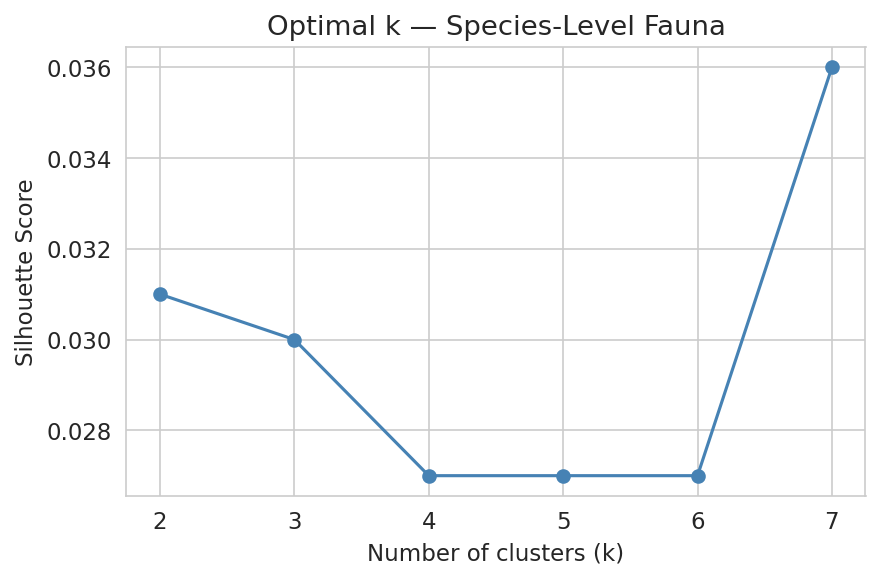

In [21]:
# ══════════════════════════════════════════════════════════════════
# 2D: Silhouette analysis to determine optimal k
# ══════════════════════════════════════════════════════════════════
from sklearn.metrics import silhouette_score

def silhouette_analysis(Z, dist_matrix, k_range=range(2, 8)):
    scores = []
    for k in k_range:
        labels_k = fcluster(Z, k, criterion='maxclust')
        if len(set(labels_k)) < 2:
            continue
        score = silhouette_score(dist_matrix, labels_k, metric='precomputed')
        scores.append({'k': k, 'silhouette': round(score, 3)})
    return pd.DataFrame(scores)

if Z_sp is not None:
    sil_sp = silhouette_analysis(Z_sp, dist_sp)
    print('Silhouette scores (species level):')
    display(sil_sp)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sil_sp['k'], sil_sp['silhouette'], 'o-', color='steelblue')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Optimal k — Species-Level Fauna')
    plt.tight_layout()
    plt.savefig('../figures/silhouette_species.png', bbox_inches='tight')
    plt.show()

In [22]:
# ══════════════════════════════════════════════════════════════════
# Save animal_cluster to the database
# ══════════════════════════════════════════════════════════════════

# 1. Add column to artwork table (if it doesn't exist yet)
try:
    conn.execute("ALTER TABLE artwork ADD COLUMN animal_cluster TEXT")
    print("✅ Added animal_cluster column to artwork table")
except Exception as e:
    print(f"Column likely already exists: {e}")

# 2. Update each artwork with its cluster assignment
conn.execute("UPDATE artwork SET animal_cluster = 'none'")  # default

for _, row in artwork_cluster.iterrows():
    conn.execute(
        "UPDATE artwork SET animal_cluster = ? WHERE cat_no = ?",
        (row['animal_cluster'], row['cat_no'])
    )

conn.commit()

# 3. Verify
verify = pd.read_sql("""
    SELECT animal_cluster, COUNT(*) as n 
    FROM artwork 
    GROUP BY animal_cluster 
    ORDER BY n DESC
""", conn)
print("\nVerification — artwork.animal_cluster:")
display(verify)

Column likely already exists: duplicate column name: animal_cluster

Verification — artwork.animal_cluster:


,animal_cluster,n
0,none,12642
1,other,1285
2,power,873
3,purity,539
4,mixed,116
